# Practical - how far back can a network remember?

> This is the **solution** notebook; the task version is `xx_rnn_memory.ipynb`.

The two RNN lectures made four claims. This practical **measures** each one on a laptop CPU
(the whole notebook runs in a few minutes, no GPU):

| Part | | The claim from the lectures | What you measure |
|---|---|---|---|
| 1 | 🧀 | an RNN is one dense layer plus **one new arrow** (L20) | build the step by hand, reproduce L20's numbers exactly, then match `nn.RNN` |
| 2 | 🧀🧀 | the gradient to step 1 shrinks like $V^{T}$ (L20) | watch autograd confirm $\lambda^T$ to machine precision, then see it in a real RNN |
| 3 | 🧀🧀🧀 | the LSTM's forget gate is a **memory dial** (L21) | a race: vanilla RNN vs LSTM, gate half-shut vs gate open |
| 4 | 🧀🧀🧀 | memory only pays when dependencies are **long** | the ch11 name inventor, now with an RNN - and *where* in a name the memory helps |

Everything uses PyTorch, but no LSTM or GRU internals: in Parts 3-4 they are black boxes, as in
the lectures. Seed `509`, everything on the CPU.

In [1]:
import time
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 509
torch.manual_seed(SEED)
torch.set_num_threads(2)          # kind to a laptop; the whole notebook is small
RED, BLUE, ORANGE, GREY = "#D90012", "#0033A0", "#F2A800", "#777777"
print("torch", torch.__version__)

torch 2.9.0+cpu


---
# Part 1 - one RNN step, by hand 🧀

L20 turned a hidden layer into an RNN with **one new arrow**: the previous state
$\mathbf{z}^{[t-1]}$ feeds back through the hidden-to-hidden weights $\mathbf{V}$:

$$\mathbf{z}^{[t]} = \tanh\big(\mathbf{W}^\top\mathbf{x}^{[t]} + \mathbf{V}^\top\mathbf{z}^{[t-1]} + \mathbf{b}\big),
\qquad \text{score} = \sigma\big(\mathbf{U}^\top\mathbf{z}^{[T]}\big)$$

L20's worked example used a toy net: a 3-word vocabulary (the first three words of the
chapter's Armenian line), a 2-d state, and these exact weights. Below they are copied from the
lecture, so your code has to reproduce the slide's numbers.

In [2]:
WORDS = ["Ես", "այս", "ամենինչ"]          # the first three words of the chapter's line
W = np.array([[0.5, -0.5], [1.0, 0.0], [0.0, 1.0]])   # 3x2: row i = word i's vector
V = np.array([[0.5, -0.5], [1.0, 0.0]])               # 2x2: hidden -> hidden
b = np.array([0.0, 0.0])
U = np.array([1.0, -1.0])                             # readout after the last word


def one_hot(i, n=3):
    v = np.zeros(n)
    v[i] = 1.0
    return v


print("W^T @ one_hot(1) =", W.T @ one_hot(1), " <- just row 1 of W: the word's own vector")

W^T @ one_hot(1) = [1. 0.]  <- just row 1 of W: the word's own vector


### Task 1.1 - the step and the unrolled forward pass 🧀

Write `rnn_step` (one application of the formula) and `rnn_forward` (start from
$\mathbf{z}^{[0]} = \mathbf{0}$, apply the step to each word in order, return every state and the
final score). The asserts below are L20's numbers, rounded to 2 decimals.

In [3]:
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))


def rnn_step(x, z_prev, W, V, b):
    '''One RNN step: tanh(W^T x + V^T z_prev + b).'''
    return np.tanh(W.T @ x + V.T @ z_prev + b)


def rnn_forward(word_ids, W, V, b, U):
    '''Feed the words in order from a zero state; return (list of states, score).'''
    z = np.zeros(V.shape[0])
    states = []
    for i in word_ids:
        z = rnn_step(one_hot(i, W.shape[0]), z, W, V, b)
        states.append(z)
    return states, float(sigmoid(U @ z))


states, score = rnn_forward([0, 1, 2], W, V, b, U)
for t, z in enumerate(states, 1):
    print(f"z[{t}] = {np.round(z, 2)}")
print(f"score = {score:.2f}")
assert np.allclose(np.round(states[0], 2), [0.46, -0.46])
assert np.allclose(np.round(states[1], 2), [0.65, -0.23])
assert np.allclose(np.round(states[2], 2), [0.10, 0.59])
assert round(score, 2) == 0.38
print("matches L20's forward-pass slide  OK")

z[1] = [ 0.46 -0.46]
z[2] = [ 0.65 -0.23]
z[3] = [0.1  0.59]
score = 0.38
matches L20's forward-pass slide  OK


### Task 1.2 - order matters 🧀

L20's shuffle test said a bag-of-words cannot tell a sentence from its shuffle. Feed the same
three words in **reverse** order through your RNN, and compare with a bag-of-words summary (the
average of the one-hots), which is what an order-blind model sees.

In [4]:
_, score_rev = rnn_forward([2, 1, 0], W, V, b, U)
bow_fwd = np.mean([one_hot(i) for i in [0, 1, 2]], axis=0)
bow_rev = np.mean([one_hot(i) for i in [2, 1, 0]], axis=0)
print(f"RNN score, forward order : {score:.2f}")
print(f"RNN score, reversed order: {score_rev:.2f}")
print(f"bag-of-words, forward vs reversed: {bow_fwd} vs {bow_rev} -> identical: "
      f"{np.array_equal(bow_fwd, bow_rev)}")
assert round(score_rev, 2) == 0.82

RNN score, forward order : 0.38
RNN score, reversed order: 0.82
bag-of-words, forward vs reversed: [0.33333333 0.33333333 0.33333333] vs [0.33333333 0.33333333 0.33333333] -> identical: True


### Task 1.3 - PyTorch computes the same thing 🧀

`nn.RNN` is exactly this recurrence. Two storage details differ from our notation:

- it stores the **transposed** matrices: `weight_ih_l0` is $\mathbf{W}^\top$ (shape hidden x
  input) and `weight_hh_l0` is $\mathbf{V}^\top$;
- it keeps **two** bias vectors, `bias_ih_l0` and `bias_hh_l0`, and simply adds them.

Copy our weights in and check that PyTorch's states equal yours.

In [5]:
def load_toy_weights(rnn, W, V, b):
    '''Copy (W, V, b) into an nn.RNN(input=3, hidden=2) so it computes our toy net.'''
    with torch.no_grad():
        rnn.weight_ih_l0.copy_(torch.tensor(W.T, dtype=torch.float32))
        rnn.weight_hh_l0.copy_(torch.tensor(V.T, dtype=torch.float32))
        rnn.bias_ih_l0.copy_(torch.tensor(b, dtype=torch.float32))
        rnn.bias_hh_l0.zero_()


rnn = nn.RNN(input_size=3, hidden_size=2, nonlinearity="tanh", batch_first=True)
load_toy_weights(rnn, W, V, b)
x = torch.tensor(np.stack([one_hot(i) for i in [0, 1, 2]])[None], dtype=torch.float32)
out, _ = rnn(x)                                        # out: (batch=1, T=3, hidden=2)
print("nn.RNN states:\n", out[0].detach().numpy().round(4))
print("our states:\n", np.array(states).round(4))
assert np.allclose(out[0].detach().numpy(), np.array(states), atol=1e-6)
print("nn.RNN == our hand-written recurrence  OK")

nn.RNN states:
 [[ 0.4621 -0.4621]
 [ 0.6463 -0.227 ]
 [ 0.0958  0.5895]]
our states:
 [[ 0.4621 -0.4621]
 [ 0.6463 -0.227 ]
 [ 0.0958  0.5895]]
nn.RNN == our hand-written recurrence  OK


---
# Part 2 - watch the gradient fade 🧀🧀

L20's diagnosis: backpropagating from step $T$ to step 1 multiplies by
$\partial\mathbf{z}^{[t]}/\partial\mathbf{z}^{[t-1]} = \mathbf{D}^{[t-1]}\mathbf{V}^\top$ at every
step - the **same** matrix, over and over. Strip away the tanh and it is pure matrix powers.

You will not derive backprop-through-time by hand. **Autograd does the backward pass; you only
measure it.**

### Task 2.1 - the linear case: exactly $\lambda^T$ 🧀🧀

Take a linear recurrence $\mathbf{h}_t = \mathbf{A}\mathbf{h}_{t-1} + \mathbf{x}_t$ with
$\mathbf{A} = \lambda \mathbf{Q}$, where $\mathbf{Q}$ is a random **orthogonal** matrix (it rotates
without stretching, so every eigenvalue of $\mathbf{A}$ has size exactly $\lambda$).

Write `influence(lam, T)`: unroll $T$ steps from a starting state $\mathbf{h}_0$ that requires a
gradient, backpropagate $\mathbf{u}\cdot\mathbf{h}_T$ for a random direction $\mathbf{u}$, and
return $\|\partial(\mathbf{u}\cdot\mathbf{h}_T)/\partial\mathbf{h}_0\| \,/\, \|\mathbf{u}\|$.
L20 predicts $\lambda^T$ exactly.

In [6]:
def influence(lam, T, H=8, seed=SEED):
    '''||d(u . h_T)/d h_0|| / ||u|| for h_t = (lam Q) h_{t-1} + x_t, Q random orthogonal.'''
    g = torch.Generator().manual_seed(seed)
    Q, _ = torch.linalg.qr(torch.randn(H, H, generator=g, dtype=torch.float64))
    A = lam * Q
    h0 = torch.randn(H, generator=g, dtype=torch.float64, requires_grad=True)
    h = h0
    for _ in range(T):
        h = A @ h + torch.randn(H, generator=g, dtype=torch.float64)
    u = torch.randn(H, generator=g, dtype=torch.float64)
    (u @ h).backward()
    return (h0.grad.norm() / u.norm()).item()


for lam in (0.8, 1.0, 1.25):
    got, want = influence(lam, 29), lam ** 29
    print(f"lambda={lam:<5} T=29: autograd {got:.6g}   lambda^T {want:.6g}")
    assert abs(got - want) / want < 1e-9
print("autograd reproduces lambda^T  OK - L20's 0.8^29 and 1.25^29, measured")

lambda=0.8   T=29: autograd 0.00154743   lambda^T 0.00154743
lambda=1.0   T=29: autograd 1   lambda^T 1
lambda=1.25  T=29: autograd 646.235   lambda^T 646.235
autograd reproduces lambda^T  OK - L20's 0.8^29 and 1.25^29, measured


### Plot it: three fates of one multiplication

The same measurement for every $T$ from 1 to 40, on a log scale. Straight lines on a log scale
are exponentials: $\lambda < 1$ starves, $\lambda > 1$ explodes, only $\lambda = 1$ survives -
and a trained network cannot sit exactly on $1$.

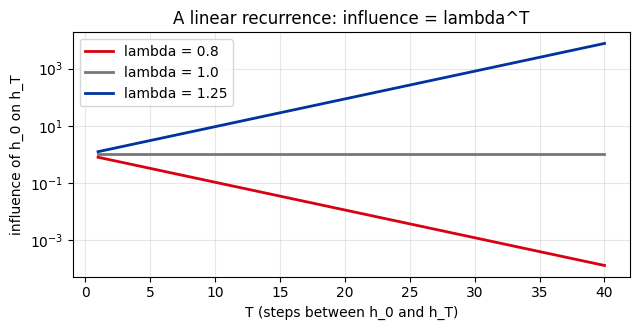

In [7]:
Ts = np.arange(1, 41)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for lam, c in ((0.8, RED), (1.0, GREY), (1.25, BLUE)):
    ax.semilogy(Ts, [influence(lam, int(T)) for T in Ts], color=c, lw=2, label=f"lambda = {lam}")
ax.set_xlabel("T (steps between h_0 and h_T)")
ax.set_ylabel("influence of h_0 on h_T")
ax.set_title("A linear recurrence: influence = lambda^T")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

### Task 2.2 - a real tanh RNN at initialization 🧀🧀

Now an actual `nn.RNN` (tanh, PyTorch's default random init, 32 hidden units), fed a
length-100 sequence of random one-hot tokens. How strongly does the input $k$ steps back still
move the final state? This is the same measurement as the left panel of L21's "Does it work?"
slide, and the helper below is reused in Part 3.

In [8]:
def final_state_sensitivity(rec, T=100, d_in=8, batch=64, seed=SEED):
    '''||d(u . h_T)/d x_t|| averaged over a batch, indexed by distance k back from the end.'''
    g = torch.Generator().manual_seed(seed)
    tok = torch.randint(0, d_in, (batch, T), generator=g)
    x = F.one_hot(tok, d_in).float().requires_grad_(True)
    out, _ = rec(x)
    u = torch.randn(out.shape[-1], generator=g)
    (out[:, -1] @ u).sum().backward()
    return x.grad.norm(dim=2).mean(dim=0).flip(0).numpy()      # index = k steps back


torch.manual_seed(SEED)
sens_rnn = final_state_sensitivity(nn.RNN(8, 32, batch_first=True))
for k in (0, 5, 10, 20, 40):
    print(f"input {k:>2} steps back: effect {sens_rnn[k]:.1e}")

input  0 steps back: effect 2.4e+00
input  5 steps back: effect 1.5e-01
input 10 steps back: effect 2.8e-03
input 20 steps back: effect 1.3e-05
input 40 steps back: effect 7.5e-11


The effect falls by orders of magnitude within a few dozen steps, and it keeps falling. Whatever
the loss at the end wants to say about the early tokens reaches them as a whisper, so the
weights that read those tokens barely learn. That is the vanishing gradient, measured.

---
# Part 3 - the memory-span race 🧀🧀🧀

L21 claimed that along the LSTM's cell highway the backward factor is just the **forget gate**:
$\partial \mathbf{c}^{[t]}/\partial \mathbf{c}^{[t-1]} = \mathrm{diag}(\mathbf{f}^{[t]})$. The gate
is a sigmoid, so its starting value is set by its **bias**: bias $0$ gives
$\sigma(0) = 0.5$, a half-shut gate; bias $3$ gives $\sigma(3) \approx 0.95$, an open one.

**Predict before you run:** an LSTM whose forget gates start half-shut - does it remember longer
than a vanilla RNN, or not?

### Task 3.1 - the dial 🧀🧀

PyTorch stacks the four LSTM gates in one bias vector, in the order **input, forget, cell,
output** - so the forget gate owns the second quarter. And it keeps two bias vectors
(`bias_ih_l0`, `bias_hh_l0`) that get added. Write `set_forget_bias(lstm, total)` so the two
together give the forget gate a starting bias of exactly `total`.

In [9]:
def set_forget_bias(lstm, total):
    '''Make bias_ih + bias_hh equal `total` on the forget-gate slice (gate order i, f, g, o).'''
    H = lstm.hidden_size
    with torch.no_grad():
        for bias in (lstm.bias_ih_l0, lstm.bias_hh_l0):
            bias[H:2 * H].fill_(total / 2)


def make_lstm(d_in, hidden, forget_bias, seed=SEED):
    torch.manual_seed(seed)
    lstm = nn.LSTM(d_in, hidden, batch_first=True)
    set_forget_bias(lstm, forget_bias)
    return lstm


_l = make_lstm(8, 32, 3.0)
fb = (_l.bias_ih_l0 + _l.bias_hh_l0)[32:64]
assert torch.allclose(fb, torch.full_like(fb, 3.0)), "forget-gate bias must total 3"
print(f"forget-gate bias = {fb[0].item():.1f}  ->  gate starts at sigmoid(3) = "
      f"{torch.sigmoid(torch.tensor(3.0)).item():.3f}  OK")

forget-gate bias = 3.0  ->  gate starts at sigmoid(3) = 0.953  OK


### Before any training: who can hear furthest back?

The same sensitivity measurement as Task 2.2, now for LSTMs with the forget gate starting at
bias 0, 1 and 3, next to the vanilla RNN.

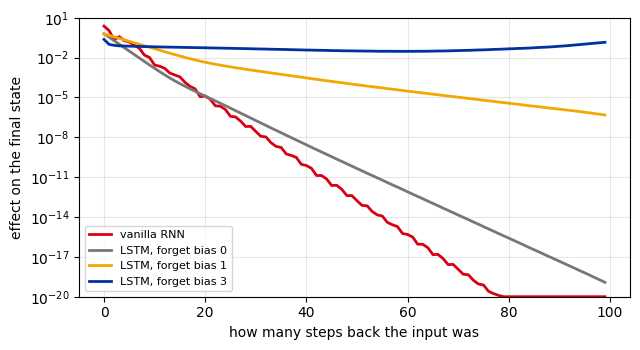

vanilla RNN            40 steps back: 7.5e-11
LSTM, forget bias 0    40 steps back: 2.7e-09
LSTM, forget bias 1    40 steps back: 3.0e-04
LSTM, forget bias 3    40 steps back: 3.7e-02


In [10]:
sens = {"vanilla RNN": sens_rnn}
for fbias in (0.0, 1.0, 3.0):
    sens[f"LSTM, forget bias {fbias:g}"] = final_state_sensitivity(make_lstm(8, 32, fbias))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for (name, s), c in zip(sens.items(), (RED, GREY, ORANGE, BLUE)):
    ax.semilogy(np.maximum(s, 1e-20), color=c, lw=2, label=name)
ax.set_ylim(1e-20, 10)
ax.set_xlabel("how many steps back the input was")
ax.set_ylabel("effect on the final state")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
for name, s in sens.items():
    print(f"{name:<22} 40 steps back: {s[40]:.1e}")

### Task 3.2 - the task: recall the first token 🧀🧀

The cleanest memory test there is. Token 1 is one of 4 **keys**; tokens 2 to $T$ are random
**distractors** from 4 other symbols; after reading all $T$ tokens the model must say which key
it saw first. Chance is 25%. Every extra step of distance is one more multiplication the
memory must survive.

Write `recall_batch(T, n, g)` returning one-hot inputs of shape `(n, T, 8)` and the key labels.

In [11]:
N_KEYS, N_DIST = 4, 4
VOCAB = N_KEYS + N_DIST


def recall_batch(T, n, g):
    '''First token = a key in 0..3, then T-1 distractors in 4..7. Returns (one-hot x, key).'''
    key = torch.randint(0, N_KEYS, (n,), generator=g)
    distract = torch.randint(N_KEYS, VOCAB, (n, T - 1), generator=g)
    seq = torch.cat([key[:, None], distract], dim=1)
    return F.one_hot(seq, VOCAB).float(), key


_x, _y = recall_batch(5, 3, torch.Generator().manual_seed(SEED))
print("shape:", tuple(_x.shape), " keys:", _y.tolist())
print("first sequence as token ids:", _x[0].argmax(1).tolist())
assert _x.shape == (3, 5, VOCAB) and (_x[:, 0].argmax(1) == _y).all()
assert (_x[:, 1:].argmax(2) >= N_KEYS).all(), "distractors must never look like a key"

shape: (3, 5, 8)  keys: [2, 0, 3]
first sequence as token ids: [2, 7, 4, 5, 6]


### The racing machinery (given)

A recurrent layer, then a linear head on the **final** state. Training is the loop you know from
ch11, with gradient clipping (L20's fix for exploding gradients) and an early stop once a
validation batch is at least 99% correct.

In [12]:
class Recall(nn.Module):
    def __init__(self, kind, forget_bias=0.0, hidden=32, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)
        if kind == "rnn":
            self.rec = nn.RNN(VOCAB, hidden, batch_first=True)
        else:
            self.rec = make_lstm(VOCAB, hidden, forget_bias, seed)
        self.head = nn.Linear(hidden, N_KEYS)

    def forward(self, x):
        out, _ = self.rec(x)
        return self.head(out[:, -1])


def race(kind, T, forget_bias=0.0, max_steps=800, seed=SEED):
    net = Recall(kind, forget_bias, seed=seed)
    opt = torch.optim.Adam(net.parameters(), lr=3e-3)
    g = torch.Generator().manual_seed(seed)
    x_val, y_val = recall_batch(T, 1000, torch.Generator().manual_seed(seed + 1))
    t0, steps, acc = time.perf_counter(), max_steps, 0.0
    for step in range(1, max_steps + 1):
        x, y = recall_batch(T, 64, g)
        loss = F.cross_entropy(net(x), y)
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step()
        if step % 50 == 0:
            with torch.no_grad():
                acc = (net(x_val).argmax(1) == y_val).float().mean().item()
            if acc >= 0.99:
                steps = step
                break
    return {"acc": acc, "steps": steps, "sec": time.perf_counter() - t0}

### Run the race

Three runners, two distances, one training budget (at most 800 steps each). This cell takes
about a minute.

In [13]:
RUNNERS = [("vanilla RNN", "rnn", 0.0), ("LSTM, gate half-shut", "lstm", 0.0),
           ("LSTM, gate open", "lstm", 3.0)]
results = {}
for T in (10, 40):
    for name, kind, fbias in RUNNERS:
        r = race(kind, T, fbias)
        results[(name, T)] = r
        done = "solved" if r["acc"] >= 0.99 else "not solved"
        print(f"T={T:<3} {name:<22} val acc {r['acc']:.2f}  ({done} after {r['steps']} "
              f"steps, {r['sec']:.0f} s)")

T=10  vanilla RNN            val acc 1.00  (solved after 100 steps, 0 s)


T=10  LSTM, gate half-shut   val acc 1.00  (solved after 250 steps, 1 s)


T=10  LSTM, gate open        val acc 1.00  (solved after 50 steps, 0 s)


T=40  vanilla RNN            val acc 0.26  (not solved after 800 steps, 9 s)


T=40  LSTM, gate half-shut   val acc 0.25  (not solved after 800 steps, 9 s)


T=40  LSTM, gate open        val acc 1.00  (solved after 100 steps, 1 s)


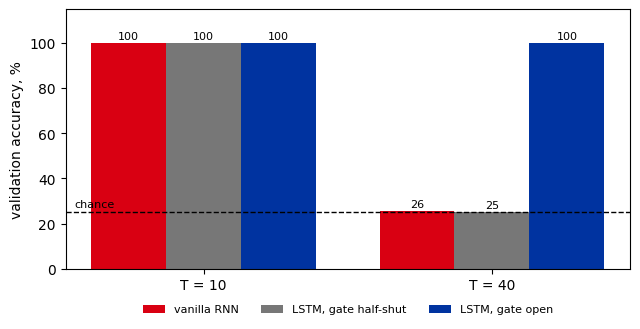

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
width = 0.26
for i, ((name, _, _), c) in enumerate(zip(RUNNERS, (RED, GREY, BLUE))):
    accs = [100 * results[(name, T)]["acc"] for T in (10, 40)]
    bars = ax.bar(np.arange(2) + (i - 1) * width, accs, width, color=c, label=name)
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding=1)
ax.axhline(100 / N_KEYS, color="k", ls="--", lw=1)
ax.text(-0.45, 100 / N_KEYS + 2, "chance", fontsize=8)
ax.set_xticks(range(2), ["T = 10", "T = 40"])
ax.set_ylim(0, 115)
ax.set_ylabel("validation accuracy, %")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
fig.tight_layout()
plt.show()

### What the race says

- At $T = 10$ everybody makes it: short memories need no special machinery.
- At $T = 40$ the picture splits. The LSTM with the **open** gate solves it in about 100
  steps; after the full 800 the vanilla RNN and the LSTM whose gates start **half-shut** are both
  still at chance. A gate stuck near $0.5$ multiplies the memory by $0.5$ at every step - the
  same disease as L20's $0.8^{29}$, so the half-shut LSTM is no better than the RNN.
- The architecture gives the network a dial; **initialisation decides where the dial starts**.
  Keras starts it open by default (`unit_forget_bias=True`); PyTorch does not.

**Try it (optional):** rerun the race with `seed=510`, or at `T = 60`. How stable is each
runner's result?

---
# Part 4 - the name inventor gets a memory 🧀🧀🧀

In ch11's practical, an MLP invented Armenian surnames from a **fixed window** of the last
$K = 3$ letters (the Bengio et al., 2003 language model). Its validation-loss ladder, in nats per
character:

| model | val loss |
|---|---|
| uniform guessing (1/39 each) | 3.664 |
| bigram (previous letter only) | 1.948 |
| MLP, window $K = 3$ | 1.673 |
| MLP, window $K = 5$ | 1.673 - **no better** |

A longer window did not help. An RNN has no window at all: its state summarises the **whole**
prefix. Does unlimited memory beat three letters? Same data, same split, same loss - so the
numbers are directly comparable.

In [15]:
RAW = ("https://raw.githubusercontent.com/HaykTarkhanyan/python_math_ml_course/main/"
       "ml/11_neural_networks/data/surnames_hy.txt")


def load_surnames():
    '''Local checkout first; on Colab download once. Raises if both fail - never a fallback.'''
    local = Path("../11_neural_networks/data/surnames_hy.txt")
    if not local.exists():
        local = Path("surnames_hy.txt")
        if not local.exists():
            req = Request(RAW, headers={"User-Agent": "python-math-ml-course/rnn-practical"})
            with urlopen(req, timeout=60) as r:          # raises on 404 / no network
                local.write_bytes(r.read())
            print(f"downloaded {RAW}")
    return local.read_text(encoding="utf-8").split()


names = load_surnames()
chars = sorted(set("".join(names)))
stoi = {c: i + 1 for i, c in enumerate(chars)}
stoi["."] = 0                                  # start AND end of a name, as in ch11
itos = {i: c for c, i in stoi.items()}
NV = len(stoi)

rng = np.random.default_rng(SEED)               # ch11's exact split: 80/20 by NAME
perm = rng.permutation(len(names))
n_tr = int(0.8 * len(names))
tr_names = [names[i] for i in perm[:n_tr]]
va_names = [names[i] for i in perm[n_tr:]]
print(f"{len(names)} surnames, vocabulary {NV}, train {len(tr_names)}, val {len(va_names)}")

689 surnames, vocabulary 39, train 551, val 138


### Task 4.1 - from names to sequences 🧀🧀

The MLP needed one training row per window. An RNN reads a whole name at once: the input is
`.` followed by the letters, the target is the letters followed by `.` - the target at every
position is simply the **next** character. Names have different lengths, so pad the batch: pad
inputs with `0` and pad targets with `-100`, which `F.cross_entropy(..., ignore_index=-100)`
skips.

In [16]:
def encode_names(batch):
    '''Names -> (inputs, targets), each (len(batch), max_len + 1), padded as described.'''
    L = max(len(n) for n in batch) + 1
    x = torch.zeros(len(batch), L, dtype=torch.long)
    y = torch.full((len(batch), L), -100, dtype=torch.long)
    for i, n in enumerate(batch):
        ids = [stoi[c] for c in n]
        x[i, 1:len(ids) + 1] = torch.tensor(ids)        # '.' (=0) then the letters
        y[i, :len(ids)] = torch.tensor(ids)             # the letters ...
        y[i, len(ids)] = stoi["."]                      # ... then '.' = "stop here"
    return x, y


_x, _y = encode_names(["պողոսյան", "ալեք"])
print("inputs :", [" ".join(itos[int(i)] for i in row) for row in _x])
print("targets:", _y.tolist())
assert _x.shape == _y.shape == (2, 9) and _y[1, 4] == 0 and _y[1, 5] == -100

inputs : ['. պ ո ղ ո ս յ ա ն', '. ա լ ե ք . . . .']
targets: [[25, 23, 17, 23, 28, 20, 1, 21, 0], [1, 11, 5, 35, 0, -100, -100, -100, -100]]


### The model and its training loop (given)

An embedding (as in ch11), a recurrent layer, and a linear layer from the state to the 39
next-character scores - at **every** position. We keep the weights from the epoch with the best
validation loss (early stopping, as in ch11).

In [17]:
class CharRNN(nn.Module):
    def __init__(self, cell="gru", d=16, hidden=64, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)
        self.emb = nn.Embedding(NV, d)
        self.rnn = {"rnn": nn.RNN, "gru": nn.GRU, "lstm": nn.LSTM}[cell](
            d, hidden, batch_first=True)
        self.out = nn.Linear(hidden, NV)

    def forward(self, x, state=None):
        o, state = self.rnn(self.emb(x), state)
        return self.out(o), state


def val_loss(model, name_list):
    x, y = encode_names(name_list)
    with torch.no_grad():
        logits, _ = model(x)
    return F.cross_entropy(logits.reshape(-1, NV), y.reshape(-1), ignore_index=-100).item()


def fit_char(cell="gru", epochs=45, seed=SEED):
    model = CharRNN(cell, seed=seed)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    g = torch.Generator().manual_seed(seed)
    best, best_ep, best_state = float("inf"), 0, None
    for ep in range(1, epochs + 1):
        model.train()
        idx = torch.randperm(len(tr_names), generator=g)
        for s in range(0, len(tr_names), 64):
            x, y = encode_names([tr_names[i] for i in idx[s:s + 64]])
            logits, _ = model(x)
            loss = F.cross_entropy(logits.reshape(-1, NV), y.reshape(-1), ignore_index=-100)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        vl = val_loss(model, va_names)
        if vl < best:
            best, best_ep = vl, ep
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, best, best_ep

In [18]:
t0 = time.perf_counter()
gru, gru_best, gru_ep = fit_char("gru")
print(f"GRU: best val loss {gru_best:.3f} at epoch {gru_ep}  ({time.perf_counter() - t0:.0f} s)")
print(f"ch11 MLP, window K=3: 1.673")

GRU: best val loss 1.605 at epoch 30  (11 s)
ch11 MLP, window K=3: 1.673


### Where does the memory pay? 🧀🧀🧀

One average hides the interesting part. Train the ch11 window model again (same data, a few
seconds) and compare the two **position by position**: the loss on the 1st letter, the 2nd,
and so on. Predict first: at which positions can a 3-letter window and a full memory differ at
all?

In [19]:
K = 3


def windows(name_list):
    '''ch11's (context, next-char) rows, plus each row's position inside its name.'''
    X, Y, P = [], [], []
    for n in name_list:
        ctx = [0] * K
        for p, ch in enumerate(n + "."):
            X.append(ctx); Y.append(stoi[ch]); P.append(p)
            ctx = ctx[1:] + [stoi[ch]]
    return torch.tensor(X), torch.tensor(Y), np.array(P)


class WindowMLP(nn.Module):
    def __init__(self, d=8, h=128):
        super().__init__()
        self.emb = nn.Embedding(NV, d)
        self.net = nn.Sequential(nn.Linear(K * d, h), nn.ReLU(), nn.Linear(h, NV))

    def forward(self, x):
        return self.net(self.emb(x).flatten(1))


torch.manual_seed(SEED)
Xtr, Ytr, _ = windows(tr_names)
Xva, Yva, Pva = windows(va_names)
mlp = WindowMLP()
opt = torch.optim.Adam(mlp.parameters(), lr=3e-3)
g = torch.Generator().manual_seed(SEED)
best, best_state = float("inf"), None
for ep in range(80):
    idx = torch.randperm(len(Xtr), generator=g)
    for s in range(0, len(Xtr), 1024):
        bidx = idx[s:s + 1024]
        loss = F.cross_entropy(mlp(Xtr[bidx]), Ytr[bidx])
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        vl = F.cross_entropy(mlp(Xva), Yva).item()
    if vl < best:
        best, best_state = vl, {k: v.clone() for k, v in mlp.state_dict().items()}
mlp.load_state_dict(best_state)
print(f"MLP K=3 retrained here: best val loss {best:.3f} (ch11 reported 1.673)")

MLP K=3 retrained here: best val loss 1.673 (ch11 reported 1.673)


letters 1-4: MLP 2.632   GRU 2.580   memory gains +0.052
letters 5-6: MLP 1.922   GRU 1.878   memory gains +0.044
letters 7-8: MLP 0.790   GRU 0.630   memory gains +0.160
letters  9+: MLP 0.079   GRU 0.051   memory gains +0.028


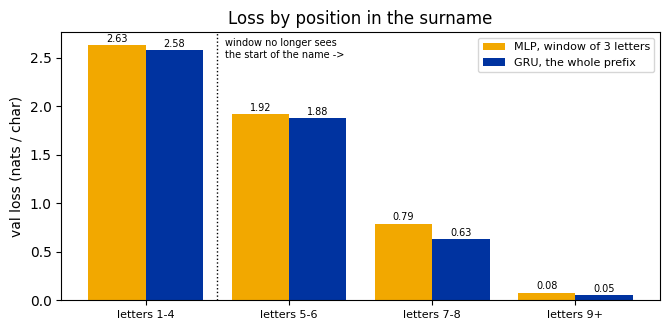

In [20]:
with torch.no_grad():
    mlp_ce = F.cross_entropy(mlp(Xva), Yva, reduction="none").numpy()
    xv, yv = encode_names(va_names)
    logits, _ = gru(xv)
    ce = F.cross_entropy(logits.permute(0, 2, 1), yv, ignore_index=-100, reduction="none")
mask = yv != -100
gru_ce = ce[mask].numpy()
gru_pos = torch.arange(yv.shape[1]).expand_as(yv)[mask].numpy()
assert np.isclose(gru_ce.mean(), gru_best, atol=1e-4) and np.isclose(mlp_ce.mean(), best, atol=1e-4)

BUCKETS = [(0, 4), (4, 6), (6, 8), (8, 20)]     # letters 1-4: a 3-letter window + start
labels = ["1-4", "5-6", "7-8", "9+"]              # pad still covers the WHOLE prefix
m_by = [mlp_ce[(Pva >= lo) & (Pva < hi)].mean() for lo, hi in BUCKETS]
g_by = [gru_ce[(gru_pos >= lo) & (gru_pos < hi)].mean() for lo, hi in BUCKETS]
for lab, m, gg in zip(labels, m_by, g_by):
    print(f"letters {lab:>3}: MLP {m:.3f}   GRU {gg:.3f}   memory gains {m - gg:+.3f}")

fig, ax = plt.subplots(figsize=(6.8, 3.4))
xs = np.arange(len(labels))
b1 = ax.bar(xs - 0.2, m_by, 0.4, color=ORANGE, label="MLP, window of 3 letters")
b2 = ax.bar(xs + 0.2, g_by, 0.4, color=BLUE, label="GRU, the whole prefix")
ax.bar_label(b1, fmt="%.2f", fontsize=7, padding=1)
ax.bar_label(b2, fmt="%.2f", fontsize=7, padding=1)
ax.axvline(0.5, color="k", ls=":", lw=1)
ax.text(0.55, max(m_by) * 0.95, "window no longer sees\nthe start of the name ->", fontsize=7)
ax.set_xticks(xs, [f"letters {l}" for l in labels], fontsize=8)
ax.set_ylabel("val loss (nats / char)")
ax.set_title("Loss by position in the surname")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Read the plot, not just the average.** For letters 1-4 both models have exactly the same
information - three letters plus the start padding cover the whole name so far - and yet the GRU
is already a little ahead. That part *cannot* be memory: it is simply a different model fitting a
bit better. Whatever memory adds must show up after letter 4, and the printout says where: the
gap is about the same at letters 5-6, then jumps at letters 7-8.

**Discuss:** why letters 7-8? Most surnames finish with «-յան» around there. Can a window of 3
letters know how long the name already is - and does a model need to know that, to decide when
to start the ending?

It is a real improvement, but a **modest** one, and the reason is the same as in Part 3:
surnames are short and mostly end in «-յան», so the dependencies that matter are only a few
letters long. Memory pays in proportion to how far back the useful information sits.

### Task 4.2 - write, don't just predict 🧀🧀

L21's generation loop: start from `.`, get the distribution over the next character, **sample**
one (divide the scores by a temperature first), feed it back in, repeat until the model samples
`.`. Keep the recurrent state between steps - that *is* the memory.

In [21]:
def sample_name(model, temp=1.0, g=None, max_len=20):
    '''Sample one surname: start from '.', sample, feed back, stop at '.'.'''
    model.eval()
    x = torch.zeros(1, 1, dtype=torch.long)            # the start symbol '.'
    state, out = None, []
    with torch.no_grad():
        for _ in range(max_len):
            logits, state = model(x, state)
            probs = F.softmax(logits[0, -1] / temp, dim=-1)
            nxt = torch.multinomial(probs, 1, generator=g).item()
            if nxt == stoi["."]:
                break
            out.append(itos[nxt])
            x = torch.tensor([[nxt]])
    return "".join(out)


g = torch.Generator().manual_seed(SEED)
samples = [sample_name(gru, temp=0.8, g=g) for _ in range(20)]
tr_set, va_set = set(tr_names), set(va_names)
print(", ".join(samples))
print(f"\ncopied from training: {sum(s in tr_set for s in samples)}/20   "
      f"real surnames it never saw (val set): {sum(s in va_set for s in samples)}/20   "
      f"invented: {sum(s not in tr_set and s not in va_set for s in samples)}/20")

աֆալյան, ալուլյան, անագարյան, խարիկյան, ադիկյան, արամարյան, սարապյան, բերտոյան, էիրանյան, գանգարյան, գոքչյան, ավթունց, ազաբեկյան, յանրանյան, մարատյան, աբաջյան, վանգորյան, շանգավիանյան, բալիկյան, աղամյան

copied from training: 2/20   real surnames it never saw (val set): 0/20   invented: 18/20


### Bonus 🎁 - do the gates matter here?

Part 3 needed the LSTM's gate for a 40-step memory. Surnames need a few letters. Swap the GRU
for a **vanilla** RNN and for an LSTM and compare best validation losses (about half a minute).

In [22]:
for cell in ("rnn", "lstm"):
    _, bl, be = fit_char(cell)
    print(f"{cell:>4}: best val loss {bl:.3f} at epoch {be}")
print(f" gru: best val loss {gru_best:.3f} at epoch {gru_ep}")

 rnn: best val loss 1.614 at epoch 27


lstm: best val loss 1.603 at epoch 29
 gru: best val loss 1.605 at epoch 30


All three land within about $0.01$ of each other: on 8-letter names the gate has nothing to do,
because nothing needs remembering for long. In Part 3, at $T = 40$, the same gate was the
difference between 100% and chance. **A tool's value depends on the data's dependencies**, not
on how clever the tool is.

---
## Wrap-up

| Claim from the lectures | What you measured |
|---|---|
| an RNN = a dense layer + one new arrow | your 5-line recurrence reproduced L20's slide and `nn.RNN` exactly |
| the gradient to step 1 shrinks like $\lambda^T$ | autograd confirmed it to machine precision; a real tanh RNN at init loses orders of magnitude within a few dozen steps |
| the forget gate is a memory dial | the open-gate LSTM remembered far past the RNN; the half-shut one did not |
| memory pays only for long dependencies | on short surnames the RNN beats a 3-letter window only a little - and part of even that small edge appears where both see the same letters; the gates changed almost nothing |

**Where this goes:** L21's two walls - the bottleneck (one vector must hold everything) and the
queue (one step at a time) - are exactly what attention removes. Next chapter.